In [ ]:
!pip install yfinance
!pip install matplotlib
!pip install statsmodels
!pip install seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR

# 1. Téléchargement robuste
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]
data = yf.download(tickers, start="2018-01-01")['Close']

# On vérifie s'il y a des colonnes vides
data = data.dropna(axis=1, how='all')

# 2. Calcul des rendements et nettoyage des NaN
returns = np.log(data / data.shift(1)).dropna()

print(f"Nombre de jours analysés : {len(returns)}")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\33768\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\33768\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\33768\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\33768\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


[*********************100%***********************]  5 of 5 completed

Nombre de jours analysés : 2081


In [7]:
def test_granger(df, target, predictor, max_lag=5):
    print(f"\n--- Test de Granger : {predictor} cause-t-il {target} ? ---")
    # Le test prend une matrice [cible, prédicteur]
    test_result = grangercausalitytests(df[[target, predictor]], maxlag=max_lag, verbose=False)

    for lag in range(1, max_lag + 1):
        p_val = test_result[lag][0]['ssr_ftest'][1]
        print(f"Lag {lag}: p-value = {p_val:.4f}")

# Exemple entre Apple et Microsoft
test_granger(returns, "AAPL", "MSFT")


--- Test de Granger : MSFT cause-t-il AAPL ? ---
Lag 1: p-value = 0.0059
Lag 2: p-value = 0.0164
Lag 3: p-value = 0.0035
Lag 4: p-value = 0.0057
Lag 5: p-value = 0.0064


C:\Users\33768\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


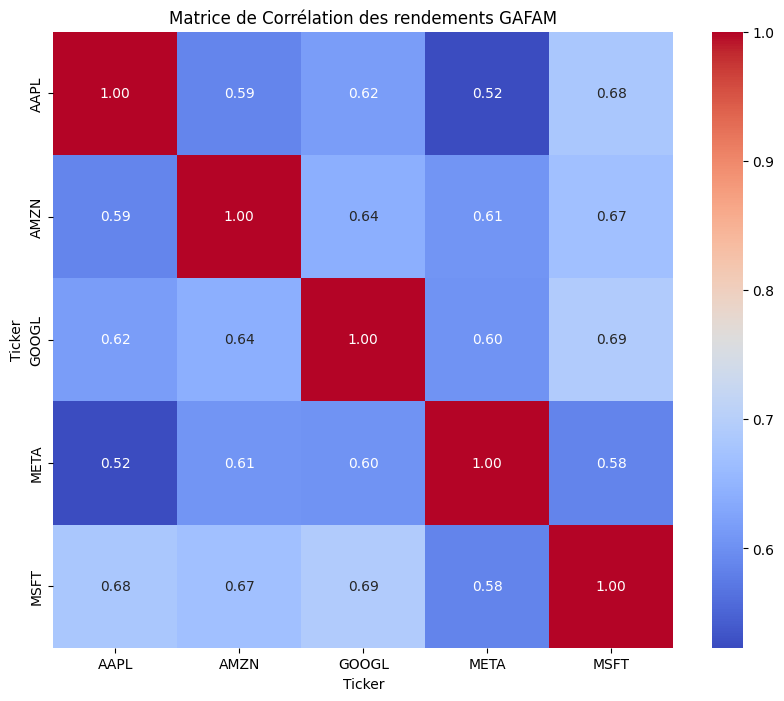

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des rendements GAFAM")
plt.show()

In [9]:
from statsmodels.tsa.api import VAR

# Initialisation du modèle
model = VAR(returns)

# Sélection de l'ordre optimal (p) basé sur les critères d'information (AIC/BIC)
order_selection = model.select_order(maxlags=15)
print(order_selection.summary())

# Ajustement du modèle (disons p=2 selon les résultats)
results = model.fit(2)
print(results.summary())

# Test de causalité de Granger global au sein du VAR
causality = results.test_causality('AAPL', ['MSFT', 'GOOGL'], kind='f')
print(causality.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -41.45     -41.44*   9.924e-19      -41.45
1      -41.49*      -41.41  9.565e-19*     -41.46*
2       -41.48      -41.33   9.685e-19      -41.42
3       -41.48      -41.26   9.696e-19      -41.40
4       -41.47      -41.18   9.765e-19      -41.37
5       -41.46      -41.10   9.904e-19      -41.33
6       -41.45      -41.03   9.971e-19      -41.29
7       -41.45      -40.96   9.963e-19      -41.27
8       -41.44      -40.88   1.005e-18      -41.24
9       -41.44      -40.82   1.002e-18      -41.21
10      -41.43      -40.73   1.017e-18      -41.18
11      -41.42      -40.65   1.031e-18      -41.14
12      -41.41      -40.57   1.042e-18      -41.10
13      -41.40      -40.50   1.048e-18      -41.07
14      -41.39      -40.42   1.058e-18      -41.04
15      -41.37      -40.34   1.076e-18      -40.99
-------------------------------

C:\Users\33768\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
